# RQ3. ¿Qué habría pasado invirtiendo 100 USD al mes?

## Pregunta e hipótesis

**Pregunta.** Un inversionista aporta 100 USD cada mes durante 10 o 20 años.
¿Cuánto pesa la elección del destino frente a la suerte del momento de inicio?
¿Y qué sacrifica por promediar en vez de invertir todo de una vez?

**H3a (a priori):** el destino del aporte (SPY, QQQ, oro, cartera 60/40) importa
más que la fecha de inicio.

**H3b (a priori):** el DCA reduce la dispersión de resultados frente a la
inversión de suma única, a costa de retorno esperado.

## Método

1. Backtest DCA con `simulate_dca_from_prices` sobre precios ajustados de fin de
   mes (dividendos reinvertidos vía adj_close). Sin look-ahead: cada compra usa
   solo el precio de su mes.
2. **Todas** las ventanas móviles de 10 y 20 años disponibles, no una fecha
   elegida a conveniencia. La cartera 60/40 (SPY/AGG, rebalanceo mensual) se
   construye como índice sintético de retornos ponderados.
3. H3a: test de Friedman sobre las ventanas comunes (bloques = fecha de inicio,
   tratamientos = destinos) y comparación del rango de medianas entre destinos
   contra el IQR medio dentro de cada destino.
4. H3b: en cada ventana de 10 años de SPY, comparar el múltiplo final del DCA
   contra invertir el mismo flujo como suma única al inicio; proporción de
   ventanas ganadoras y dispersión de ambos.

**Nota de cobertura (RQ0):** QQQ tiene ventanas de 20 años desde 2019 (n = 89) y
GLD solo 21; las comparaciones a 20 años usan la intersección común (n = 21) y
se leen con esa cautela.

In [1]:
import sys
from pathlib import Path

if str(Path.cwd().parent) not in sys.path:
    sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from src.backtest import dca_all_windows, simulate_dca_from_prices
from src.db import get_engine

eng = get_engine()
monthly = pd.read_sql(
    "SELECT ticker, month_end, monthly_ret FROM v_monthly_returns", eng)
wide = monthly.pivot(index="month_end", columns="ticker", values="monthly_ret")
wide.index = pd.to_datetime(wide.index)

pair = wide[["SPY", "AGG"]].dropna()
r6040 = 0.6 * pair["SPY"] + 0.4 * pair["AGG"]
idx6040 = 100 * (1 + r6040).cumprod()

def windows_from_prices(prices, years, monthly_usd=100):
    months = years * 12
    rows = []
    for i in range(len(prices) - months):
        w = prices.iloc[i:i + months]
        res = simulate_dca_from_prices(w, monthly_usd)
        rows.append({"start": w.index[0],
                     "mm": res["value"].iloc[-1] / res["contributed"].iloc[-1]})
    return pd.DataFrame(rows).set_index("start")["mm"]

def destinations(years):
    dest = {tk: dca_all_windows(tk, 100, years).set_index("start")["money_multiple"]
            for tk in ["SPY", "QQQ", "GLD"]}
    dest["60/40"] = windows_from_prices(idx6040, years)
    return dest

dest10 = destinations(10)
dest20 = destinations(20)

## Resultados

### Distribución del múltiplo final por destino (dinero final / dinero aportado)

In [2]:
def dist_table(dest):
    return pd.DataFrame({
        k: {"ventanas": len(v), "p5": v.quantile(0.05), "p25": v.quantile(0.25),
            "mediana": v.median(), "p75": v.quantile(0.75), "p95": v.quantile(0.95)}
        for k, v in dest.items()}).T.round(2)

print("Ventanas de 10 años:")
display(dist_table(dest10))
print("Ventanas de 20 años:")
display(dist_table(dest20))

Ventanas de 10 años:


,ventanas,p5,p25,mediana,p75,p95
SPY,283.0,1.02,1.33,1.66,1.94,2.22
QQQ,209.0,1.14,1.77,2.27,2.67,3.22
GLD,141.0,0.99,1.08,1.25,1.38,2.40
60/40,154.0,1.43,1.50,1.56,1.63,1.74


Ventanas de 20 años:


,ventanas,p5,p25,mediana,p75,p95
SPY,163.0,2.09,2.30,2.68,3.58,4.38
QQQ,89.0,3.91,5.14,6.39,7.13,8.01
GLD,21.0,2.25,2.55,2.68,3.22,3.59
60/40,34.0,2.25,2.45,2.56,2.68,2.75


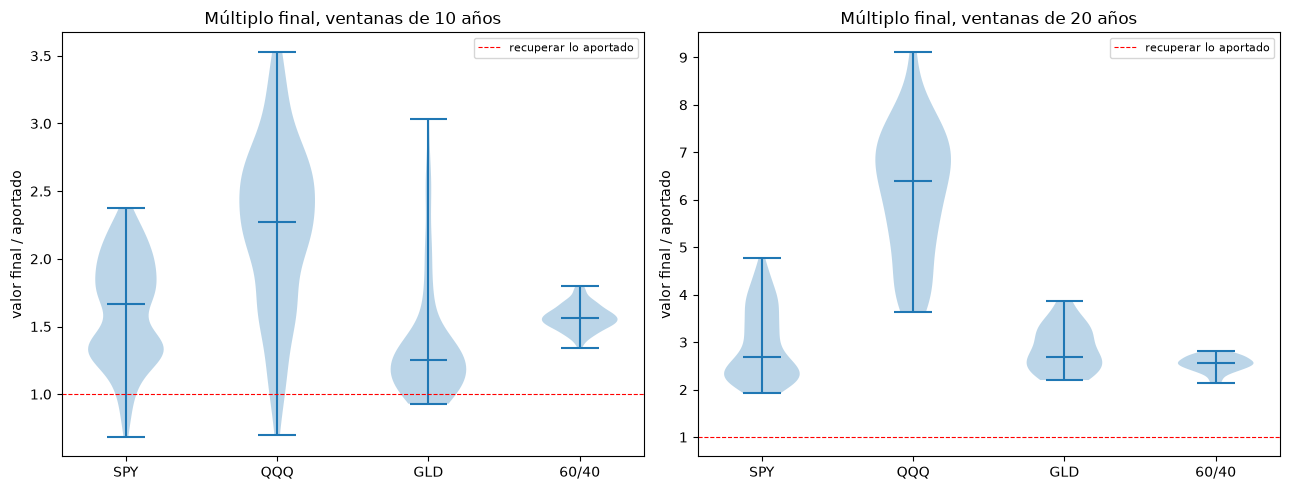

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
for ax, dest, yrs in [(axes[0], dest10, 10), (axes[1], dest20, 20)]:
    data = [v.values for v in dest.values()]
    vp = ax.violinplot(data, showmedians=True)
    ax.set_xticks(range(1, len(dest) + 1), dest.keys())
    ax.axhline(1, color="red", lw=0.8, ls="--", label="recuperar lo aportado")
    ax.set_title(f"Múltiplo final, ventanas de {yrs} años")
    ax.set_ylabel("valor final / aportado")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Lectura.** A 10 años, la mediana va de 1.25x (GLD) a 2.27x (QQQ); la cartera
60/40 destaca por su distribución comprimida (p5 = 1.43, p95 = 1.74: resultado
casi garantizado pero modesto). A 20 años ninguna ventana histórica de ningún
destino terminó por debajo de lo aportado.

### Contraste H3a: ¿destino o momento?

In [4]:
for dest, yrs in [(dest10, 10), (dest20, 20)]:
    common = pd.DataFrame(dest).dropna()
    fried = stats.friedmanchisquare(*[common[k] for k in common.columns])
    between = common.median().max() - common.median().min()
    within = (common.quantile(0.75) - common.quantile(0.25)).mean()
    print(f"{yrs} años (ventanas comunes n = {len(common)}): "
          f"Friedman chi2 = {fried.statistic:.1f}, p = {fried.pvalue:.2e}")
    print(f"  rango de medianas entre destinos: {between:.2f} | "
          f"IQR medio dentro de cada destino: {within:.2f} | "
          f"ratio destino/momento: {between / within:.1f}x")

10 años (ventanas comunes n = 141): Friedman chi2 = 367.4, p = 2.49e-79
  rango de medianas entre destinos: 1.29 | IQR medio dentro de cada destino: 0.32 | ratio destino/momento: 4.1x
20 años (ventanas comunes n = 21): Friedman chi2 = 57.9, p = 1.69e-12
  rango de medianas entre destinos: 4.98 | IQR medio dentro de cada destino: 0.47 | ratio destino/momento: 10.5x


**Lectura.** El efecto del destino domina: a 10 años el rango de medianas entre
destinos (1.29) es 4 veces el IQR atribuible a la fecha de inicio (0.32); a 20
años la razón sube a 10x. Friedman rechaza igualdad de destinos con p < 1e-11 en
ambos horizontes. **H3a confirmada.**

### Contraste H3b: DCA vs suma única (SPY, ventanas de 10 años)

Ventanas: 283 | suma única gana en 90.8%
Mediana:  suma única 2.28x vs DCA 1.66x
Desv est: suma única 0.94  vs DCA 0.38
Peor caso: suma única 0.68x vs DCA 0.68x


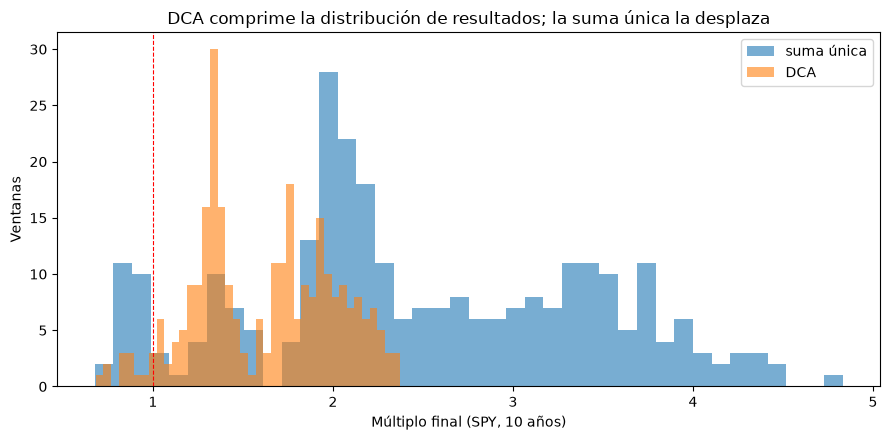

In [5]:
prices_spy = pd.read_sql(
    "SELECT month_end, adj_close_eom FROM v_monthly_returns "
    "WHERE ticker='SPY' ORDER BY month_end", eng).set_index("month_end")["adj_close_eom"]
prices_spy.index = pd.to_datetime(prices_spy.index)

months = 120
rows = []
for i in range(len(prices_spy) - months):
    w = prices_spy.iloc[i:i + months]
    res = simulate_dca_from_prices(w, 100)
    rows.append({"start": w.index[0],
                 "dca": res["value"].iloc[-1] / res["contributed"].iloc[-1],
                 "lump": w.iloc[-1] / w.iloc[0]})
h3b = pd.DataFrame(rows).set_index("start")
wins = (h3b["lump"] > h3b["dca"]).mean()
print(f"Ventanas: {len(h3b)} | suma única gana en {wins:.1%}")
print(f"Mediana:  suma única {h3b['lump'].median():.2f}x vs DCA {h3b['dca'].median():.2f}x")
print(f"Desv est: suma única {h3b['lump'].std():.2f}  vs DCA {h3b['dca'].std():.2f}")
print(f"Peor caso: suma única {h3b['lump'].min():.2f}x vs DCA {h3b['dca'].min():.2f}x")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(h3b["lump"], bins=40, alpha=0.6, label="suma única", color="#1f77b4")
ax.hist(h3b["dca"], bins=40, alpha=0.6, label="DCA", color="#ff7f0e")
ax.axvline(1, color="red", lw=0.8, ls="--")
ax.set_xlabel("Múltiplo final (SPY, 10 años)")
ax.set_ylabel("Ventanas")
ax.set_title("DCA comprime la distribución de resultados; la suma única la desplaza")
ax.legend()
plt.tight_layout()
plt.show()

**Lectura.** La suma única termina por encima del DCA en el 90.8% de las
ventanas (mediana 2.28x vs 1.66x): matemáticamente esperable, el dinero pasa
más tiempo invertido. Pero la desviación estándar del DCA es menos de la mitad
(0.38 vs 0.94). **H3b confirmada**: el DCA es un mecanismo de reducción de
varianza (y de disciplina conductual), no de maximización de retorno. Nota: la
comparación asume que se dispone del capital completo al inicio; para quien
ahorra de su salario mes a mes, el DCA no es una elección sino la única opción,
y este resultado describe el costo de oportunidad de esa restricción.

### La pregunta original: 100 USD/mes en SPY durante 20 años

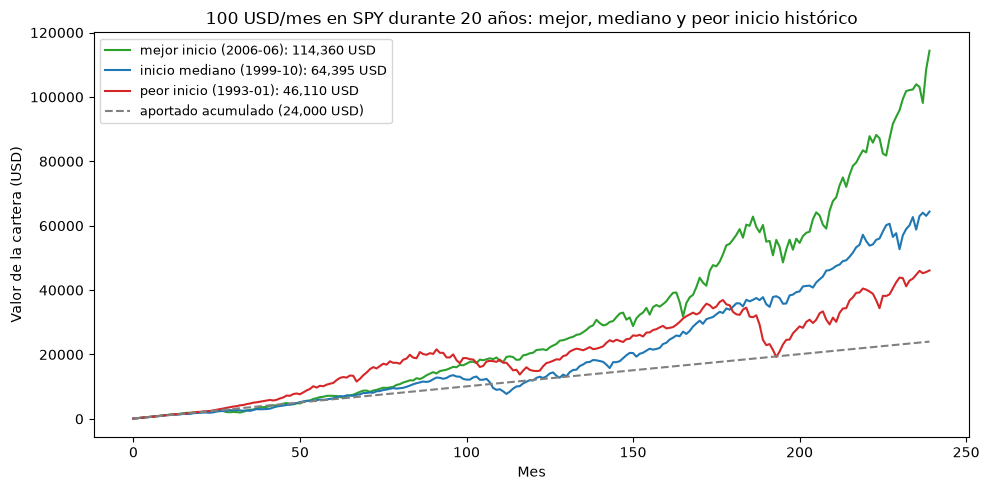

In [6]:
mm20 = dest20["SPY"]
best, worst = mm20.idxmax(), mm20.idxmin()
med_start = (mm20 - mm20.median()).abs().idxmin()

fig, ax = plt.subplots(figsize=(10, 5))
for start, label, color in [(best, "mejor inicio", "#2ca02c"),
                            (med_start, "inicio mediano", "#1f77b4"),
                            (worst, "peor inicio", "#d62728")]:
    i = prices_spy.index.get_loc(pd.Timestamp(start))
    w = prices_spy.iloc[i:i + 240]
    res = simulate_dca_from_prices(w, 100)
    ax.plot(range(240), res["value"],
            label=f"{label} ({start:%Y-%m}): {res['value'].iloc[-1]:,.0f} USD", color=color)
ax.plot(range(240), [100 * (i + 1) for i in range(240)],
        color="gray", ls="--", label="aportado acumulado (24,000 USD)")
ax.set_xlabel("Mes")
ax.set_ylabel("Valor de la cartera (USD)")
ax.set_title("100 USD/mes en SPY durante 20 años: mejor, mediano y peor inicio histórico")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Discusión y limitaciones

- Sin costos de transacción ni impuestos; con aportes mensuales pequeños los
  costos fijos por operación penalizarían más al DCA (dirección declarada).
- adj_close asume reinversión íntegra e inmediata de dividendos.
- Ventanas móviles solapadas: los estadísticos descriptivos son válidos, pero las
  ventanas no son independientes; por eso H3a usa Friedman por bloques y no un
  ANOVA que asuma independencia.
- Sesgo de supervivencia (RQ0): SPY y QQQ representan mercados que sobrevivieron
  y prosperaron; el resultado no es una ley universal.

## Conclusión ejecutiva

En la historia disponible, la elección del destino pesó entre 4 y 10 veces más
que la suerte del momento de inicio: QQQ multiplicó por 6.4 el aporte mediano a
20 años, SPY por 2.7, y ninguna ventana de 20 años de ningún destino perdió
dinero nominal. Frente a la suma única, el DCA cedió retorno mediano (1.66x vs
2.28x a 10 años en SPY) a cambio de recortar la dispersión a menos de la mitad.
H3a y H3b: confirmadas.

In [7]:
out = Path.cwd().parent / "docs" / "resultados"
out.mkdir(parents=True, exist_ok=True)
lines = [
    "# RQ3. Backtest DCA",
    "",
    "**H3a (el destino importa más que el momento): CONFIRMADA.** "
    "Friedman p < 1e-11 en ambos horizontes; rango de medianas entre destinos = 4x (10a) y 10x (20a) el IQR por fecha de inicio.",
    "",
    "**H3b (DCA reduce dispersión a costa de retorno): CONFIRMADA.** "
    f"Suma única gana en {wins:.0%} de ventanas de 10 años de SPY (mediana 2.28x vs 1.66x) pero con std 0.94 vs 0.38 del DCA.",
    "",
    "- Medianas 20 años: QQQ 6.39x (n=89), SPY 2.68x (n=163), GLD 2.68x (n=21), 60/40 2.56x (n=34)",
    "- Ninguna ventana de 20 años de ningún destino terminó por debajo de lo aportado",
    "- 60/40 a 10 años: la distribución más comprimida (p5 1.43, p95 1.74)",
    "",
    "Caveats: sin costos ni impuestos; ventanas solapadas; sesgo de supervivencia; cobertura desigual a 20 años (GLD n=21).",
]
(out / "rq3.md").write_text("\n".join(lines), encoding="utf-8")
print("escrito docs/resultados/rq3.md")

escrito docs/resultados/rq3.md
